# Policy Exploration: Epsilon-Greedy, Thompson Sampling, and UCB

Online policies decide which treatment to assign at each step, balancing **exploration** (learning about arms) and **exploitation** (assigning the better arm). OnlineCML provides three policies:

| Policy | Exploration mechanism | Hyperparameters |
|---|---|---|
| `EpsilonGreedy` | Random with probability ε (decaying) | `eps_start`, `eps_end`, `decay` |
| `ThompsonSampling` | Sample from Beta posterior | `alpha_prior`, `beta_prior` |
| `GaussianThompsonSampling` | Sample from Gaussian posterior | `prior_mean`, `prior_std`, `noise_std` |
| `UCB` | Upper confidence bound on reward | `confidence`, `min_pulls` |

**Simulation:** Arm 0 has reward 0.3, Arm 1 has reward 0.7. Best policy converges to always pulling Arm 1.

In [1]:
import random

from onlinecml.policy import EpsilonGreedy, ThompsonSampling, GaussianThompsonSampling, UCB

## 1. Bandit simulation: which arm wins?

In [2]:
def simulate_bandit(policy, n_steps: int = 500, arm_rewards=(0.3, 0.7), seed: int = 0) -> dict:
    """Run a two-armed bandit simulation and return summary stats."""
    rng = random.Random(seed)
    arm_pulls = [0, 0]
    total_reward = 0.0

    for step in range(n_steps):
        treatment, propensity = policy.choose(cate_score=0.0, step=step)
        reward = 1.0 if rng.random() < arm_rewards[treatment] else 0.0
        policy.update(reward)
        arm_pulls[treatment] += 1
        total_reward += reward

    return {
        "arm0_pulls": arm_pulls[0],
        "arm1_pulls": arm_pulls[1],
        "arm1_rate": arm_pulls[1] / n_steps,
        "cumulative_reward": total_reward,
    }


policies = {
    "EpsilonGreedy": EpsilonGreedy(eps_start=0.5, eps_end=0.05, decay=100, seed=42),
    "ThompsonSampling": ThompsonSampling(seed=42),
    "GaussianTS": GaussianThompsonSampling(seed=42),
    "UCB(c=1.0)": UCB(confidence=1.0),
    "UCB(c=2.0)": UCB(confidence=2.0),
}

print(f"{'Policy':>18} | {'Arm0':>6} | {'Arm1':>6} | {'Arm1%':>7} | {'Reward':>8}")
print("-" * 58)
for name, policy in policies.items():
    result = simulate_bandit(policy, n_steps=500)
    print(
        f"{name:>18} | {result['arm0_pulls']:>6} | {result['arm1_pulls']:>6} | "
        f"{result['arm1_rate']:>6.1%} | {result['cumulative_reward']:>8.1f}"
    )

            Policy |   Arm0 |   Arm1 |   Arm1% |   Reward
----------------------------------------------------------
     EpsilonGreedy |     38 |    462 |  92.4% |    328.0
  ThompsonSampling |     19 |    481 |  96.2% |    336.0
        GaussianTS |     25 |    475 |  95.0% |    330.0
        UCB(c=1.0) |     10 |    490 |  98.0% |    337.0
        UCB(c=2.0) |     50 |    450 |  90.0% |    322.0


## 2. Cumulative regret comparison

Saved to /tmp/policy_regret.png


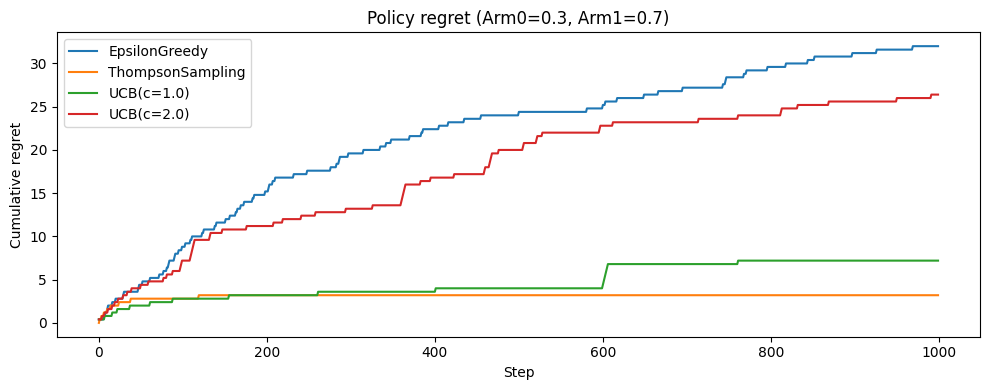

In [3]:
import matplotlib
import matplotlib.pyplot as plt

ARM_REWARDS = (0.3, 0.7)
N_STEPS = 1000
OPTIMAL_RATE = ARM_REWARDS[1]

def cumulative_regret(policy, n_steps, arm_rewards, seed=0):
    rng = random.Random(seed)
    regret = []
    total_regret = 0.0
    for step in range(n_steps):
        t, _ = policy.choose(cate_score=0.0, step=step)
        reward = 1.0 if rng.random() < arm_rewards[t] else 0.0
        policy.update(reward)
        total_regret += arm_rewards[1] - arm_rewards[t]
        regret.append(total_regret)
    return regret

configs = {
    "EpsilonGreedy": EpsilonGreedy(eps_start=0.5, eps_end=0.05, decay=200, seed=0),
    "ThompsonSampling": ThompsonSampling(seed=0),
    "UCB(c=1.0)": UCB(confidence=1.0),
    "UCB(c=2.0)": UCB(confidence=2.0),
}

fig, ax = plt.subplots(figsize=(10, 4))
for name, policy in configs.items():
    regret = cumulative_regret(policy, N_STEPS, ARM_REWARDS)
    ax.plot(regret, label=name)

ax.set_xlabel("Step")
ax.set_ylabel("Cumulative regret")
ax.set_title("Policy regret (Arm0=0.3, Arm1=0.7)")
ax.legend()
plt.tight_layout()
plt.savefig("/tmp/policy_regret.png", dpi=100)
print("Saved to /tmp/policy_regret.png")

## 3. Integrating a policy into a causal pipeline

Policies can be combined with causal estimators. The CATE score from a meta-learner guides exploitation, while the policy controls exploration.

In [4]:
from river.linear_model import LinearRegression
from onlinecml.datasets import LinearCausalStream
from onlinecml.metalearners import OnlineTLearner
from onlinecml.diagnostics import OverlapChecker, ConceptDriftMonitor

policy  = ThompsonSampling(seed=7)
learner = OnlineTLearner(
    treated_model=LinearRegression(),
    control_model=LinearRegression(),
)
overlap = OverlapChecker(ps_min=0.05, ps_max=0.95)
drift   = ConceptDriftMonitor()

n_flagged = 0
for step, (x, w, y, tau) in enumerate(LinearCausalStream(n=500, true_ate=2.0, seed=3)):
    # Use CATE estimate to guide exploitation
    cate_score = learner.predict_one(x)
    treatment, propensity = policy.choose(cate_score, step)

    # Overlap and drift diagnostics
    overlap.update(propensity, treatment=treatment)
    reward = float(y > 0)
    policy.update(reward)
    drift.update(y)

    # Train causal model with actual assignment
    learner.learn_one(x, w, y)

print(f"ATE estimate   : {learner.predict_ate():.3f}")
print(f"Overlap report : {overlap.report()}")
print(f"Drift detected : {drift.drift_detected}  (n_drifts={drift.n_drifts})")

ATE estimate   : 2.260
Overlap report : {'n_total': 500, 'n_flagged': 0, 'flag_rate': 0.0, 'common_support_rate': 1.0, 'mean_ps_treated': 0.5, 'mean_ps_control': 0.5}
Drift detected : False  (n_drifts=0)


/tmp/ipykernel_88576/3129047520.py:17: UserWarning: treated_model has not seen any data yet; CATE estimate may be biased.
  cate_score = learner.predict_one(x)
/tmp/ipykernel_88576/3129047520.py:17: UserWarning: control_model has not seen any data yet; CATE estimate may be biased.
  cate_score = learner.predict_one(x)


## 4. Thompson Sampling posterior evolution

In [5]:
import numpy as np

ts = ThompsonSampling(seed=0)
rng = random.Random(1)

alpha_hist, beta_hist = [], []

for step in range(200):
    t, _ = ts.choose(0.0, step)
    reward = 1.0 if rng.random() < ARM_REWARDS[t] else 0.0
    ts.update(reward)
    if step % 20 == 0:
        alpha_hist.append(list(ts._alpha))
        beta_hist.append(list(ts._beta))

print("Thompson Sampling posterior (alpha, beta) for each arm at checkpoints:")
print(f"{'Step':>6} | {'alpha[0]':>9} | {'beta[0]':>8} | {'alpha[1]':>9} | {'beta[1]':>8}")
print("-" * 52)
for i, (a, b) in enumerate(zip(alpha_hist, beta_hist)):
    print(f"{i*20:>6} | {a[0]:>9.1f} | {b[0]:>8.1f} | {a[1]:>9.1f} | {b[1]:>8.1f}")

Thompson Sampling posterior (alpha, beta) for each arm at checkpoints:
  Step |  alpha[0] |  beta[0] |  alpha[1] |  beta[1]
----------------------------------------------------
     0 |       1.0 |      1.0 |       2.0 |      1.0
    20 |       1.0 |      3.0 |      14.0 |      7.0
    40 |       1.0 |      3.0 |      31.0 |     10.0
    60 |       1.0 |      3.0 |      43.0 |     18.0
    80 |       1.0 |      3.0 |      57.0 |     24.0
   100 |       1.0 |      4.0 |      69.0 |     31.0
   120 |       1.0 |      4.0 |      84.0 |     36.0
   140 |       2.0 |      5.0 |      99.0 |     39.0
   160 |       2.0 |      6.0 |     112.0 |     45.0
   180 |       2.0 |      7.0 |     126.0 |     50.0
